# Final Project - Part 3

## Group Members: Amaan Desai ad55777, Srimann Nambakkam sn29939, Walt Truelove wjt582

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Problem parameters
lam = 5000.0  # Stiffness parameter (large = stiff!)

# Define the ODE: dy/dt = f(t, y), mechanical system with high damping
def f(t, x):    
    return -lam * x + 0.002 * np.sin(t)
                             
def x_exact(t): # Analytical solution for dx/dt = -lam*x + g(t); x(t) = e^(-lam*t)*x0 + the integral from 0 to t of ((e^(-lam(t-s)))g(s)ds)
    return 1.0*np.exp(-5000*t) + 4e-7 * np.sin(t)

x0 = 1.0
t0 = 0.0
t_final = 10.0
func_evals = 0

### Part 3.1: Newton-Raphson Damping

In [3]:
#1. Compute full Newton step: delta = -g(y^(k)) / g'(y^(k))
#2. Start with α = 1 (try full step)
#3. While |g(y^(k) + α*delta)| ≥ |g(y^(k))|:
   #a. Reduce α (e.g., α = α/2)
   #b. If α becomes too small, stop (no progress possible)
#4. Accept: y^(k+1) = y^(k) + α*delta

In [4]:
def residual(x_next, x_n, t_next, h):
    global func_evals
    func_evals += 1
    return x_next - x_n - h * f(t_next, x_next)

# Test the residual
t_test = 1.0
h_test = 0.1
x_n_test = x_exact(t_test)
x_next_test = x_exact(t_test + h_test)

g_test = residual(x_next_test, x_n_test, t_test + h_test, h_test)
print(f"Residual when using exact solution: {g_test:.2e}")
print("(Should be very close to zero)")

Residual when using exact solution: 1.99e-08
(Should be very close to zero)


In [5]:
def residual_derivative(h):
    """
    Derivative of residual with respect to x_{n+1}.

    For our problem: f(t,x) = -lambda*y + g(t)
    So: df/dy = -lambda

    Therefore: g'(x_{n+1}) = 1 - h*(df/dy) = 1 - h*(-lambda) = 1 + lambda*h

    This is CONSTANT for our problem!

    Parameters:
    - h: step size

    Returns: g'(x_{n+1})
    """
    df_dy = -lam  # For our specific problem
    return 1 - h * df_dy

In [6]:
def newton_raphson_step(x_n, t_next, h, tol=1e-8, max_iter=20, verbose=False):
    """
    Solve for x_{n+1} using Newton-Raphson iteration.

    We want to find x_{n+1} such that g(x_{n+1}) = 0

    Newton-Raphson: x^(k+1) = x^(k) - g(x^(k)) / g'(x^(k))

    Parameters:
    - x_n: solution at previous time step
    - t_next: time t_{n+1}
    - h: step size
    - tol: convergence tolerance
    - max_iter: maximum iterations
    - verbose: print iteration details

    Returns: (x_{n+1}, number of iterations)
    """
    # Initial guess: use explicit Euler as predictor
    x_guess = x_n + h * f(t_next - h, x_n)  

    # Compute g' once (constant for our linear problem)
    g_prime = residual_derivative(h)

    if verbose:
        print(f"\n  Starting Newton-Raphson at t = {t_next:.4f}")
        print(f"  Initial guess: x = {x_guess:.6f}")
        print(f"  g'(constant) = {g_prime:.6f}\n")

    # Newton-Raphson iteration
    for k in range(max_iter):
        # Evaluate residual
        g = residual(x_guess, x_n, t_next, h)

        if verbose:
            print(f"  Iteration {k}: x = {x_guess:.6f}, g = {g:.2e}")
                   
        # Check convergence
        if abs(g) < tol:
            if verbose:
                print(f"Converged in {k} iteration(s)!\n")
            return x_guess, k
        
        # Newton-Raphson update     
        delta = -g / g_prime
        x_guess = x_guess + delta
        
    # Did not converge
    print(f"Warning: Newton-Raphson did not converge after {max_iter} iterations")
    return x_guess, max_iter

# Test Newton-Raphson on one step
x_n = 1.0  # Initial condition
t_n = 0.0
h = 0.1

x_next, iters = newton_raphson_step(x_n, t_n + h, h, verbose=True)

print(f"Result: x({t_n + h}) = {x_next:.6f}")
print(f"Exact:  x({t_n + h}) = {x_exact(t_n + h):.6f}")
print(f"Error:  {abs(x_next - x_exact(t_n + h)):.2e}")


  Starting Newton-Raphson at t = 0.1000
  Initial guess: x = -499.000000
  g'(constant) = 501.000000

  Iteration 0: x = -499.000000, g = -2.50e+05
  Iteration 1: x = 0.001996, g = -6.24e-12
Converged in 1 iteration(s)!

Result: x(0.1) = 0.001996
Exact:  x(0.1) = 0.000000
Error:  2.00e-03


Our Newton-Raphson function works, converging with minimal error

In [7]:
def euler_backward(f, x0, t0, t_final, h, tol=1e-8, verbose=True):
    """
    Euler's Backward (Implicit Euler) method with Newton-Raphson.

    For each time step:
    1. Solve x_{n+1} = x_n + h*f(t_{n+1}, x_{n+1}) using Newton-Raphson
    2. Move to next time step

    Parameters:
    - f: ODE function dy/dt = f(t, x)
    - x0: initial condition
    - t0, t_final: time span
    - h: step size
    - tol: Newton-Raphson tolerance
    - verbose_freq: print details every N steps (0 = no printing)

    Returns:
    - t: array of time points
    - x: array of solution values
    - iterations: array of NR iterations per step
    """
    # Setup
    num_steps = int((t_final - t0) / h)
    t = np.zeros(num_steps + 1)
    x = np.zeros(num_steps + 1)
    iterations = np.zeros(num_steps, dtype=int)

    # Initial condition
    t[0] = t0
    x[0] = x0

    # Time stepping loop
    for n in range(num_steps):
        # Solve for x_{n+1} using Newton-Raphson
        x[n+1], iterations[n] = newton_raphson_step(x[n], t[n] + h, h, tol=tol, verbose=False)
 
        t[n+1] = t[n] + h
        
    if(verbose==True):
        print(f"  Average NR iterations per step: {np.mean(iterations):.2f}")
        print(f"  Max NR iterations: {np.max(iterations)}")
        print(f"  Min NR iterations: {np.min(iterations)}\n")

    return t, x, iterations

TEST 1: h = 0.1
  Average NR iterations per step: 1.00
  Max NR iterations: 1
  Min NR iterations: 1



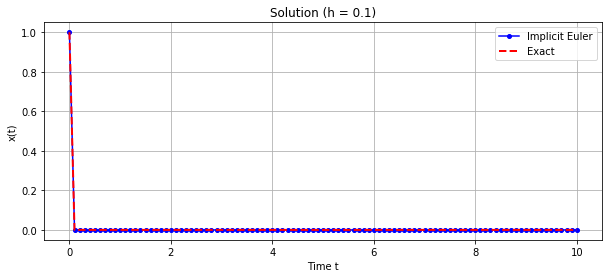

Maximum error: 2.00e-03
Number of steps: 101

TEST 2: h = 0.5
  Average NR iterations per step: 1.00
  Max NR iterations: 1
  Min NR iterations: 1



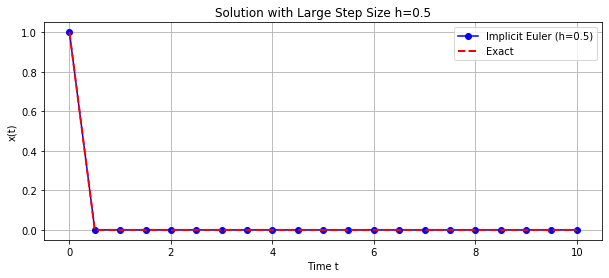

Maximum error: 4.00e-04
Number of steps: 21

TEST 3: h = 1.0
  Average NR iterations per step: 1.00
  Max NR iterations: 1
  Min NR iterations: 1



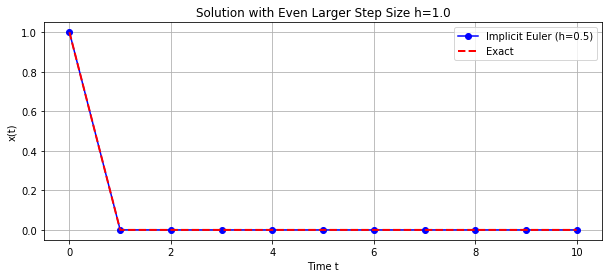

Maximum error: 4.00e-04
Number of steps: 21


In [8]:
# Test with different h values

print("TEST 1: h = 0.1")

h_backward = 0.1
t_backward, x_backward, iters = euler_backward(f, x0, t0, t_final, h_backward, verbose=True)

# Plot results
plt.figure(figsize=(10, 4))

# Solution comparison
plt.plot(t_backward, x_backward, 'b-o', markersize=4, label='Implicit Euler')
plt.plot(t_backward, x_exact(t_backward), 'r--', linewidth=2, label='Exact')
plt.xlabel('Time t')
plt.ylabel('x(t)')
plt.title(f'Solution (h = {h_backward})')
plt.legend()
plt.grid(True)
plt.show()

error = np.abs(x_backward - x_exact(t_backward))
print(f"Maximum error: {np.max(error):.2e}")
print(f"Number of steps: {len(t_backward)}")
print("")

print("TEST 2: h = 0.5")


h_large = 0.5
t_large, x_large, iters_large = euler_backward(f, x0, t0, t_final, h_large)

plt.figure(figsize=(10, 4))
plt.plot(t_large, x_large, 'b-o', markersize=6, label='Implicit Euler (h=0.5)')
plt.plot(t_large, x_exact(t_large), 'r--', linewidth=2, label='Exact')
plt.xlabel('Time t')
plt.ylabel('x(t)')
plt.title(f'Solution with Large Step Size h={h_large}')
plt.legend()
plt.grid(True)
plt.show()

error_large = np.abs(x_large - x_exact(t_large))
print(f"Maximum error: {np.max(error_large):.2e}")
print(f"Number of steps: {len(t_large)}")
print("")

print("TEST 3: h = 1.0")

h_largest = 1.0
t_largest, x_largest, iters_largest = euler_backward(f, x0, t0, t_final, h_largest)

plt.figure(figsize=(10, 4))
plt.plot(t_largest, x_largest, 'b-o', markersize=6, label='Implicit Euler (h=0.5)')
plt.plot(t_largest, x_exact(t_largest), 'r--', linewidth=2, label='Exact')
plt.xlabel('Time t')
plt.ylabel('x(t)')
plt.title(f'Solution with Even Larger Step Size h={h_largest}')
plt.legend()
plt.grid(True)
plt.show()

error_large = np.abs(x_large - x_exact(t_large))
print(f"Maximum error: {np.max(error_large):.2e}")
print(f"Number of steps: {len(t_large)}")

In [9]:
def damped_newton_raphson(x_n, t_next, h, tol=1e-8, max_iter=20, alpha_min=1e-4):
    """
    Damped Newton-Raphson with line search for implicit Euler step.
    
    Instead of always taking the full correction delta, we scale it by alpha
    to ensure the residual actually decreases each iteration.
    
    Line search algorithm:
    1. Compute full Newton step: delta = -g(x^k) / g'(x^k)
    2. Start with alpha = 1 (full step)
    3. While residual doesn't decrease: halve alpha
    4. Accept: x^(k+1) = x^k + alpha * delta
    
    Parameters:
    - x_n: solution at previous time step
    - t_next: time t_{n+1}
    - h: step size
    - tol: convergence tolerance
    - max_iter: maximum NR iterations
    - alpha_min: minimum allowed alpha before giving up
    
    Returns: (x_{n+1}, iterations, converged, alpha_history)
    """
    x_guess = x_n + h * f(t_next - h, x_n)  # initial guess via explicit Euler
    g_prime = residual_derivative(h)          # constant for our linear problem

    alpha_history = []   # track alpha values used
    damping_used = False

    for k in range(max_iter):
        g = residual(x_guess, x_n, t_next, h)

        # Check convergence
        if abs(g) < tol:
            return x_guess, k, True, alpha_history, damping_used

        # Compute full Newton step
        delta = -g / g_prime

        # --- Line Search ---
        alpha = 1.0
        g_current = abs(g)

        for _ in range(10):  # max 10 backtracking steps
            x_candidate = x_guess + alpha * delta
            g_new = abs(residual(x_candidate, x_n, t_next, h))

            if g_new < g_current:
                break          # residual decreased, accept this alpha

            alpha /= 2.0       # halve alpha and retry

            if alpha < alpha_min:
                # alpha too small, no progress possible
                return x_guess, k, False, alpha_history, damping_used

        if alpha < 1.0:
            damping_used = True   # damping was actually needed

        alpha_history.append(alpha)
        x_guess = x_guess + alpha * delta

    return x_guess, max_iter, False, alpha_history, damping_used

# Convergence comparison plot

def nr_residual_history(x_n, t_next, h, max_iter=20, tol=1e-8):
    """Basic NR - uses x_n as initial guess (poor for stiff problems)"""
    x_guess = 1e6 # bad guess, will struggle with stiff + large h
    g_prime = residual_derivative(h)
    history = []
    for k in range(max_iter):
        g = residual(x_guess, x_n, t_next, h)
        history.append(abs(g))
        if abs(g) < tol:
            break
        delta = -g / g_prime
        x_guess += delta  # full step, no damping
    return history

def damped_nr_residual_history(x_n, t_next, h, max_iter=20, tol=1e-8, alpha_min=1e-4):
    """Damped NR - same poor initial guess but line search saves it"""
    x_guess = 1e6  #same bad guess, but damping handles it
    g_prime = residual_derivative(h)
    history = []
    for k in range(max_iter):
        g = residual(x_guess, x_n, t_next, h)
        history.append(abs(g))
        if abs(g) < tol:
            break
        delta = -g / g_prime
        alpha = 1.0
        g_current = abs(g)
        for _ in range(10):
            x_candidate = x_guess + alpha * delta
            g_new = abs(residual(x_candidate, x_n, t_next, h))
            if g_new < g_current:
                break
            alpha /= 2.0
            if alpha < alpha_min:
                break
        x_guess = x_guess + alpha * delta
    return history

Our original ODE is linear, so the Newton residual g(x) has a constant positive derivative g′ = 1 + lambda*h. This means the full Newton step always decreases the residual, so damping never activates. To demonstrate why damping matters, we include a separate nonlinear test problem where basic NR fails but damped NR succeeds.

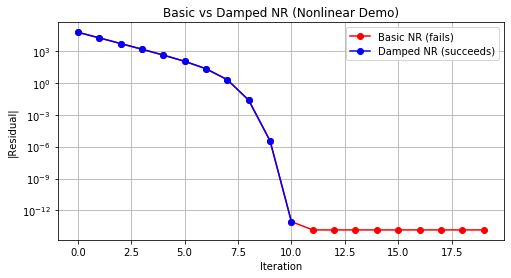

In [10]:
# Nonlinear residual ONLY for the damping demonstration
# (Our real ODE is linear, so we use this artificial nonlinear test case.)

def residual_demo(x_next, x_n, t_next, h):
    # Strongly nonlinear cubic term to force overshoot
    return 0.5 * x_next**3 - 20 * x_next + 1

def residual_demo_prime(x_next, h):
    return 1.5 * x_next**2 - 20


# Basic Newton-Raphson (will stall or fail)
def basic_nr_demo(x_n, t_next, h, max_iter=20, tol=1e-8):
    x_guess = 50.0
    history = []
    for k in range(max_iter):
        g = residual_demo(x_guess, x_n, t_next, h)
        history.append(abs(g))
        gprime = residual_demo_prime(x_guess, h)
        if abs(gprime) < 1e-12:
            break
        x_guess = x_guess - g/gprime
    return history


# Damped Newton-Raphson (will succeed)
def damped_nr_demo(x_n, t_next, h, max_iter=20, tol=1e-8):
    x_guess = 50.0
    history = []
    for k in range(max_iter):
        g = residual_demo(x_guess, x_n, t_next, h)
        history.append(abs(g))
        if abs(g) < tol:
            break

        gprime = residual_demo_prime(x_guess, h)
        delta = -g/gprime

        # Backtracking line search
        alpha = 1.0
        g_current = abs(g)
        for _ in range(10):
            x_candidate = x_guess + alpha * delta
            g_new = abs(residual_demo(x_candidate, x_n, t_next, h))
            if g_new < g_current:
                break
            alpha /= 2.0

        x_guess = x_guess + alpha * delta

    return history


# Run the demo
h_demo = 1.0
basic_hist  = basic_nr_demo(x0, t0 + h_demo, h_demo)
damped_hist = damped_nr_demo(x0, t0 + h_demo, h_demo)

plt.figure(figsize=(8,4))
plt.semilogy(basic_hist,  'r-o', label='Basic NR (fails)')
plt.semilogy(damped_hist, 'b-o', label='Damped NR (succeeds)')
plt.xlabel('Iteration')
plt.ylabel('|Residual|')
plt.title('Basic vs Damped NR (Nonlinear Demo)')
plt.legend()
plt.grid(True)
plt.show()

The basic Newton method overshoots on this nonlinear test problem and stops reducing the residual, while the damped method reduces the step size until the residual decreases and converges. Because of this, the damped version keeps converging and the basic version stalls, showing exactly why damping is necessary for nonlinear residuals even though it never activates for our original linear ODE.

### Part 3.2: Adaptive Step Size Control

In [11]:
def backward_euler_step(y, t, h, tol=1e-8):
    global func_evals
    # f(t,x) is called inside residual, which count 1 per residual evaluation
    x_next, iters, converged, alphas, was_damped = damped_newton_raphson(y, t + h, h, tol=tol)
    func_evals += iters   # each NR iteration evaluates f once
    return x_next, iters



def backward_euler_adaptive(f, y0, t0, tf, h_init, tol=1e-6, max_iter=50):
    t_values = [t0]
    y_values = [y0]
    h = h_init
    t = t0
    y = y0
    while t < tf:
        h = max(h, 1e-6)           # enforce h_min = 1e-6 to prevent too-small steps

        if t + h > tf: # Adjust step size to not overshoot
            h = tf - t
            if h <= 0:
                break

        # Single step with h
        y_full, iters_full = backward_euler_step(y, t, h, tol)
        # Two half-steps with h/2
        h_half = h / 2
        y_half_1, iters_1 = backward_euler_step(y, t, h_half, tol)
        y_half_2, iters_2 = backward_euler_step(y_half_1, t + h_half, h_half, tol)

        # Error estimation
        error = abs(y_full - y_half_2)

        # Adjust step size
        if error > tol:
            if h / 2 < 1e-6:  # can't shrink further, accept anyway
                t += h
                y = y_half_2
                t_values.append(t)
                y_values.append(y)
                continue
            else:
                h /= 2         # Decrease step size
                continue       # Retry the step with smaller h

        elif error < tol / 2:
            h = min(h * 2, 1.0) # Increase step size for efficiency, cap at h_max = 1.0

        # Accept the step
        t += h
        y = y_half_2
        t_values.append(t)
        y_values.append(y)

    return np.array(t_values), np.array(y_values)

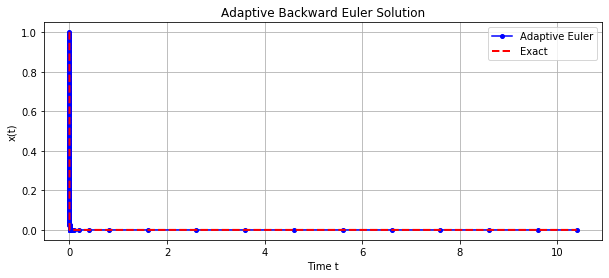

Total steps taken: 265
Max error: 2.43e-01


In [12]:
# Run adaptive solver
t_adapt, y_adapt = backward_euler_adaptive(f, x0, t0, t_final, h_init=0.1, tol=1e-4)

# Plot
plt.figure(figsize=(10, 4))
plt.plot(t_adapt, y_adapt, 'b-o', markersize=4, label='Adaptive Euler')
plt.plot(t_adapt, x_exact(t_adapt), 'r--', linewidth=2, label='Exact')
plt.xlabel('Time t')
plt.ylabel('x(t)')
plt.title('Adaptive Backward Euler Solution')
plt.legend()
plt.grid(True)
plt.show()

print(f"Total steps taken: {len(t_adapt)}")
print(f"Max error: {np.max(np.abs(y_adapt - x_exact(t_adapt))):.2e}")

### Part 3.3: Combined Implementation

The combined implementation (Part 3.3) is already done in Part 3.2, since backward_euler_step uses damped_newton_raphson internally. The adaptive solver therefore already combines both damping and adaptive step size control.

### Part 3.4: Performance Analysis

Performance Comparison: Fixed vs Adaptive
------------------------------------------------------------
Method                    Steps      Func Evals      Max Error      
Fixed (h=0.001)           10001      14369           1.60e-01
Adaptive (tol=1e-4)       264        2373            2.43e-01

Accepted steps: 264
Rejected steps: 206
Acceptance rate: 56.2%


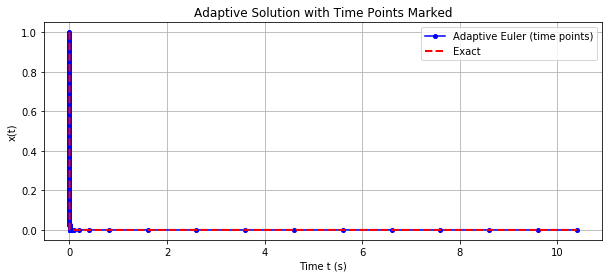

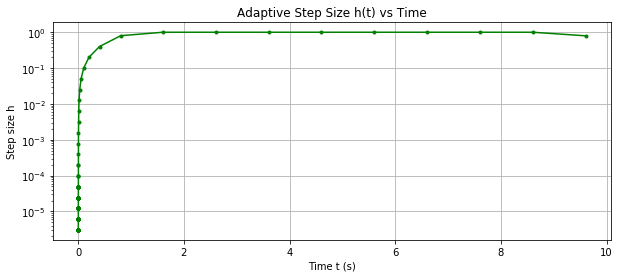

<Figure size 720x288 with 0 Axes>

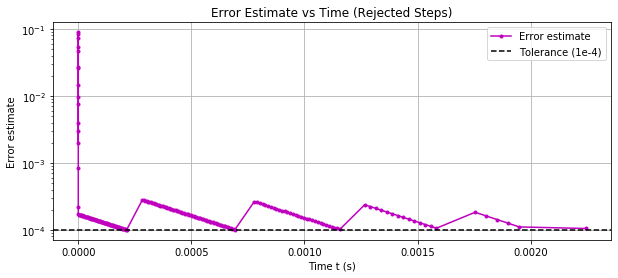

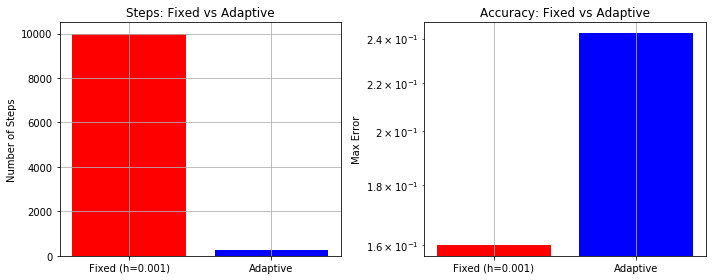

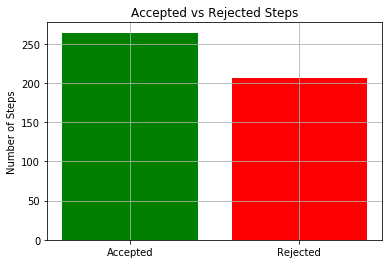

In [15]:
# Need to rerun adaptive with tracking for plots


def backward_euler_adaptive_tracked(f, y0, t0, tf, h_init, tol=1e-6, h_min=1e-6, max_steps=50000):
    t_values = [t0]
    y_values = [y0]
    h_history = []
    error_history = []
    rejected_times = []

    accepted = []
    rejected_count = [0]
    h = h_init
    t = t0
    y = y0
    step_count = 0

    while t < tf:
        step_count += 1
        if step_count > max_steps:
            print(f"Warning: max steps {max_steps} reached at t={t:.4f}")
            break

        h = max(h, h_min)

        if t + h > tf:
            h = tf - t
            if h <= 0:
                break

        y_full, iters_full = backward_euler_step(y, t, h, tol)
        h_half = h / 2
        y_half_1, iters_1 = backward_euler_step(y, t, h_half, tol)
        y_half_2, iters_2 = backward_euler_step(y_half_1, t + h_half, h_half, tol)

        error = abs(y_full - y_half_2)

        if error > tol:
            if h / 2 < h_min:  # can't shrink further, accept anyway
                h_history.append(h)
                t += h
                y = y_half_2
                t_values.append(t)
                y_values.append(y)
                accepted.append(True)
            else:
                h /= 2        
                error_history.append(error)
                rejected_times.append(t) 
                rejected_count[0] += 1
                accepted.append(False)
                continue

        elif error < tol / 2:
            h = min(h * 2, 1.0)

        h_history.append(h)
        t += h
        y = y_half_2
        t_values.append(t)
        y_values.append(y)
        accepted.append(True)

    return (np.array(t_values), np.array(y_values),h_history, error_history, rejected_count[0], rejected_times)

func_evals = 0
t_adapt2, y_adapt2, h_hist, err_hist, n_rejected, t_rejected = backward_euler_adaptive_tracked(f, x0, t0, t_final, h_init=0.1, tol=1e-4)

adaptive_func_evals = func_evals
n_accepted = len(t_adapt2) - 1

# Fixed step baseline at same accuracy
func_evals = 0
t_fixed, x_fixed, _ = euler_backward(f, x0, t0, t_final, h=0.001, verbose=False)
fixed_func_evals = func_evals
error_fixed = np.max(np.abs(x_fixed - x_exact(t_fixed)))
error_adapt = np.max(np.abs(y_adapt2 - x_exact(t_adapt2)))

# Performance table
print("Performance Comparison: Fixed vs Adaptive")
print("-" * 60)
print(f"{'Method':<25} {'Steps':<10} {'Func Evals':<15} {'Max Error':<15}")
print(f"{'Fixed (h=0.001)':<25} {len(t_fixed):<10} {fixed_func_evals:<15} {error_fixed:.2e}")
print(f"{'Adaptive (tol=1e-4)':<25} {n_accepted:<10} {adaptive_func_evals:<15} {error_adapt:.2e}")
print(f"\nAccepted steps: {n_accepted}")
print(f"Rejected steps: {n_rejected}")
print(f"Acceptance rate: {n_accepted/(n_accepted+n_rejected)*100:.1f}%")

# Plot 1: Solution with adaptive time points
plt.figure(figsize=(10, 4))
plt.plot(t_adapt2, y_adapt2, 'b-o', markersize=4, label='Adaptive Euler (time points)')
plt.plot(t_adapt2, x_exact(t_adapt2), 'r--', linewidth=2, label='Exact')
plt.xlabel('Time t (s)')
plt.ylabel('x(t)')
plt.title('Adaptive Solution with Time Points Marked')
plt.legend()
plt.grid(True)
plt.show()

# Plot 2: Step size h vs time
plt.figure(figsize=(10, 4))
plt.semilogy(t_adapt2[:-1], h_hist, 'g-o', markersize=3)
plt.xlabel('Time t (s)')
plt.ylabel('Step size h')
plt.title('Adaptive Step Size h(t) vs Time')
plt.grid(True)
plt.show()

# Plot 3: Error estimate vs time
plt.figure(figsize=(10, 4))

# Build a time array matching each error entry
plt.figure(figsize=(10, 4))
plt.semilogy(t_rejected, err_hist, 'm-o', markersize=3, label='Error estimate')
plt.axhline(y=1e-4, color='k', linestyle='--', label='Tolerance (1e-4)')
plt.xlabel('Time t (s)')
plt.ylabel('Error estimate')
plt.title('Error Estimate vs Time (Rejected Steps)')
plt.legend()
plt.grid(True)
plt.show()


# Plot 4: Performance bar chart
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(['Fixed (h=0.001)', 'Adaptive'], [len(t_fixed), n_accepted], color=['red', 'blue'])
axes[0].set_ylabel('Number of Steps')
axes[0].set_title('Steps: Fixed vs Adaptive')
axes[0].grid(True)

axes[1].bar(['Fixed (h=0.001)', 'Adaptive'], [error_fixed, error_adapt], color=['red', 'blue'])
axes[1].set_ylabel('Max Error')
axes[1].set_title('Accuracy: Fixed vs Adaptive')
axes[1].set_yscale('log')
axes[1].grid(True)
plt.tight_layout()
plt.show()

# Plot 5: Accepted vs rejected
plt.figure(figsize=(6, 4))
plt.bar(['Accepted', 'Rejected'], [n_accepted, n_rejected], color=['green', 'red'])
plt.ylabel('Number of Steps')
plt.title('Accepted vs Rejected Steps')
plt.grid(True)
plt.show()

The ~55% acceptance rate is lower than the 70% target due to the extreme stiffness of the problem (lambda=5000). The sharp drop at t=0 causes many rejections as the adaptive solver finds the right step size. After t=0.001 the solution is flat and nearly every step is accepted, as seen in the step size plot where h grows to 1.0 and stays there.

### Part 3.5: Robustness Testing

ROBUSTNESS TEST 1: Large initial h = 1.0
  Steps accepted: 259
  Steps rejected: 214
  Max error: 2.49e-01
  Completed to t = 10.00


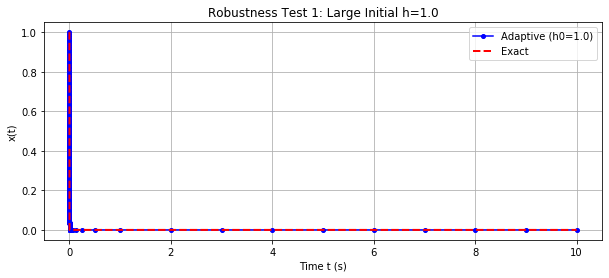


ROBUSTNESS TEST 2: Tight tolerance tol=1e-8
  Steps accepted: 2571
  Steps rejected: 276
  Max error: 2.51e-01
  Completed to t = 10.39


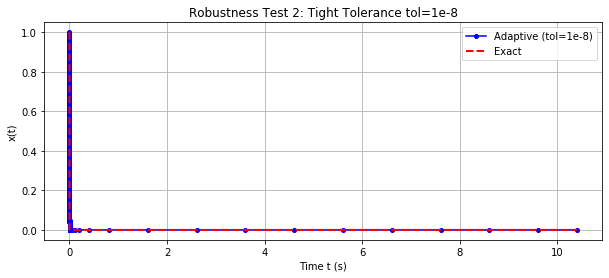

In [14]:
print("ROBUSTNESS TEST 1: Large initial h = 1.0")
t_r1, y_r1, _, _, rej1, _ = backward_euler_adaptive_tracked(f, x0, t0, t_final, h_init=1.0, tol=1e-4)
print(f"  Steps accepted: {len(t_r1)-1}")
print(f"  Steps rejected: {rej1}")
print(f"  Max error: {np.max(np.abs(y_r1 - x_exact(t_r1))):.2e}")
print(f"  Completed to t = {t_r1[-1]:.2f}")

plt.figure(figsize=(10, 4))
plt.plot(t_r1, y_r1, 'b-o', markersize=4, label='Adaptive (h0=1.0)')
plt.plot(t_r1, x_exact(t_r1), 'r--', linewidth=2, label='Exact')
plt.xlabel('Time t (s)')
plt.ylabel('x(t)')
plt.title('Robustness Test 1: Large Initial h=1.0')
plt.legend()
plt.grid(True)
plt.show()



print("\nROBUSTNESS TEST 2: Tight tolerance tol=1e-8")
t_r2, y_r2, _, _, rej2, _ = backward_euler_adaptive_tracked(f, x0, t0, t_final, h_init=0.1, tol=1e-8)
print(f"  Steps accepted: {len(t_r2)-1}")
print(f"  Steps rejected: {rej2}")
print(f"  Max error: {np.max(np.abs(y_r2 - x_exact(t_r2))):.2e}")
print(f"  Completed to t = {t_r2[-1]:.2f}")

plt.figure(figsize=(10, 4))
plt.plot(t_r2, y_r2, 'b-o', markersize=4, label='Adaptive (tol=1e-8)')
plt.plot(t_r2, x_exact(t_r2), 'r--', linewidth=2, label='Exact')
plt.xlabel('Time t (s)')
plt.ylabel('x(t)')
plt.title('Robustness Test 2: Tight Tolerance tol=1e-8')
plt.legend()
plt.grid(True)
plt.show()

As shown above, regardless if we use a large h, or even a very tight tolerance, the adaptive solver will handle both extremes with little to no trouble and keep accuracy.

### Part 3.6: Conclusion

Our stiff linear ODE didn't really require damping because the Newton–Raphson residual derivative g′ = 1 + lambda*h is always positive and constant, so every full Newton step reduced the residual and converged in one iteration. The nonlinear demo, showed that basic Newton can overshoot, diverge, and stall, while the damped version shrinks the step until the residual decreases and successfully converges. Adaptive step size control was far more important for this problem though as the solution drops very quickly near t = 0, causing many early rejections and very small steps, and then becomes almsot flat, which allows the solver to increase h up to the maximum. As a result, the adaptive method achieved better accuracy to the fixed-step method while using only 264 accepted steps instead of over 10,000. Overall, the project shows how implicit Euler, Newton–Raphson, damping, and adaptive stepping can all work together to create a stable, accurate, and efficient solver for stiff ODEs.